# Task 1: Exploring and Visualizing the Iris Dataset
**Objective:** Load, inspect, and visualize the Iris dataset to understand data trends and distributions.

**Dataset:** Iris Dataset (loaded via seaborn)

**Skills:** Data loading, EDA, matplotlib & seaborn visualization

In [1]:
# --- Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set global style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load the Dataset

In [2]:
# Load Iris dataset from seaborn
df = sns.load_dataset('iris')

print('Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Shape: (150, 5)

Column Names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Dataset Summary Statistics

In [3]:
# .info() gives data types and null counts
print('--- Dataset Info ---')
df.info()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
# .describe() gives statistical summary for numeric columns
print('--- Statistical Summary ---')
df.describe()

--- Statistical Summary ---


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
# Check for missing values
print('Missing Values per Column:')
print(df.isnull().sum())

# Check class distribution
print('\nClass Distribution:')
print(df['species'].value_counts())

Missing Values per Column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 3. Scatter Plot — Feature Relationships

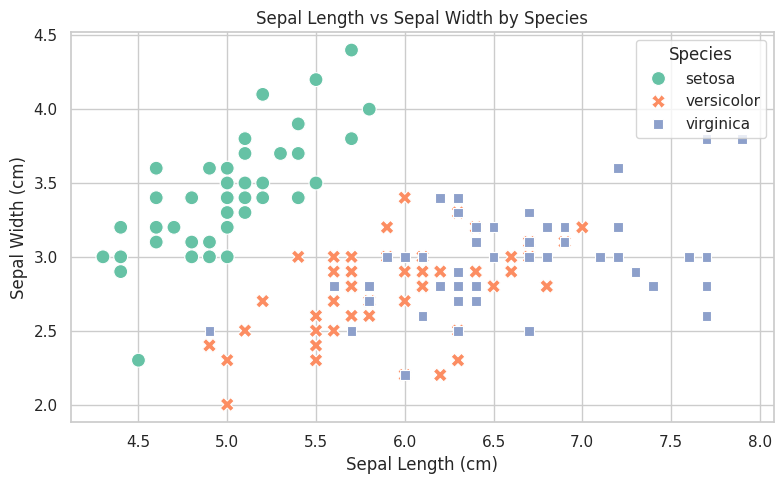

In [6]:
# Scatter plot: Sepal Length vs Sepal Width, colored by species
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='sepal_length', y='sepal_width',
                hue='species', style='species', s=100)
plt.title('Sepal Length vs Sepal Width by Species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Species')
plt.tight_layout()
plt.show()

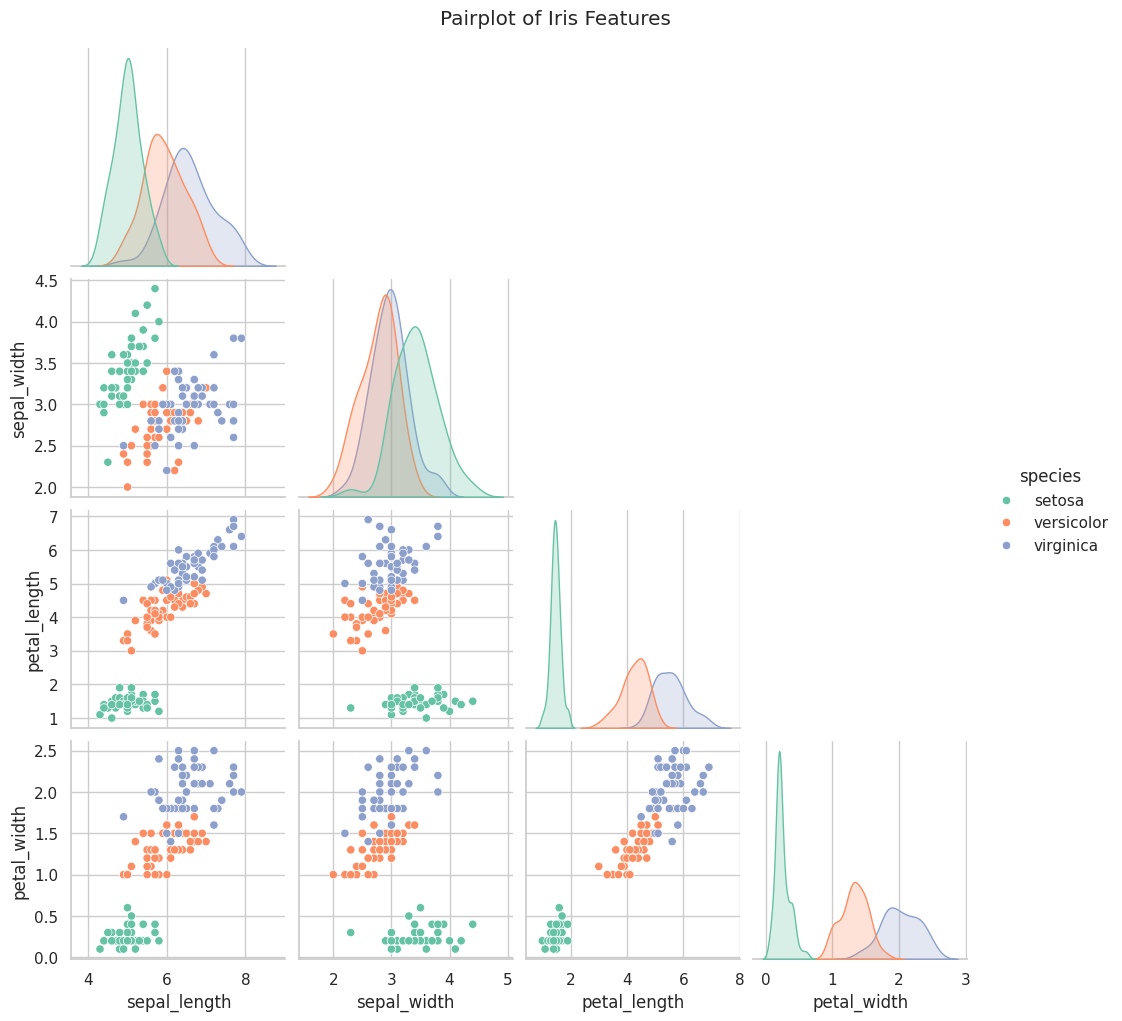

In [7]:
# Pairplot: all feature combinations
sns.pairplot(df, hue='species', diag_kind='kde', corner=True)
plt.suptitle('Pairplot of Iris Features', y=1.02)
plt.show()

## 4. Histograms — Value Distributions

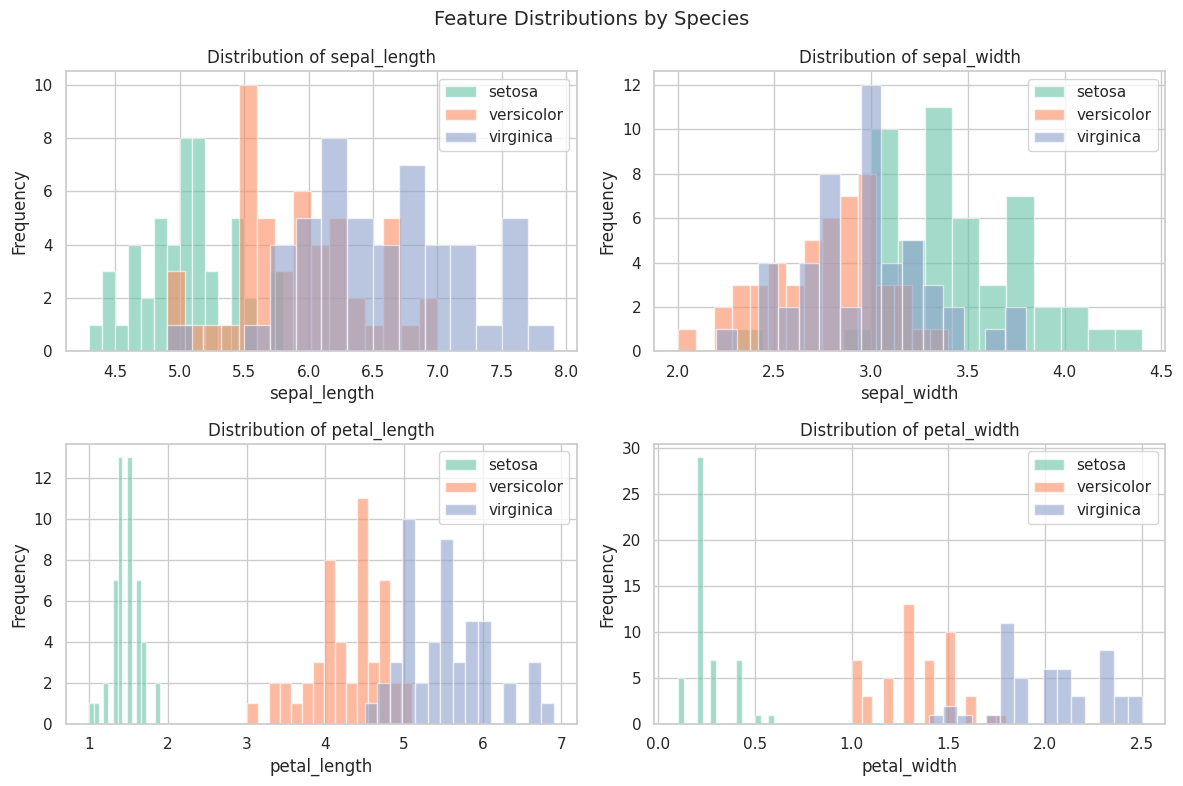

In [8]:
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    for species in df['species'].unique():
        subset = df[df['species'] == species][feature]
        axes[i].hist(subset, bins=15, alpha=0.6, label=species)
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.suptitle('Feature Distributions by Species', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Box Plots — Outlier Detection

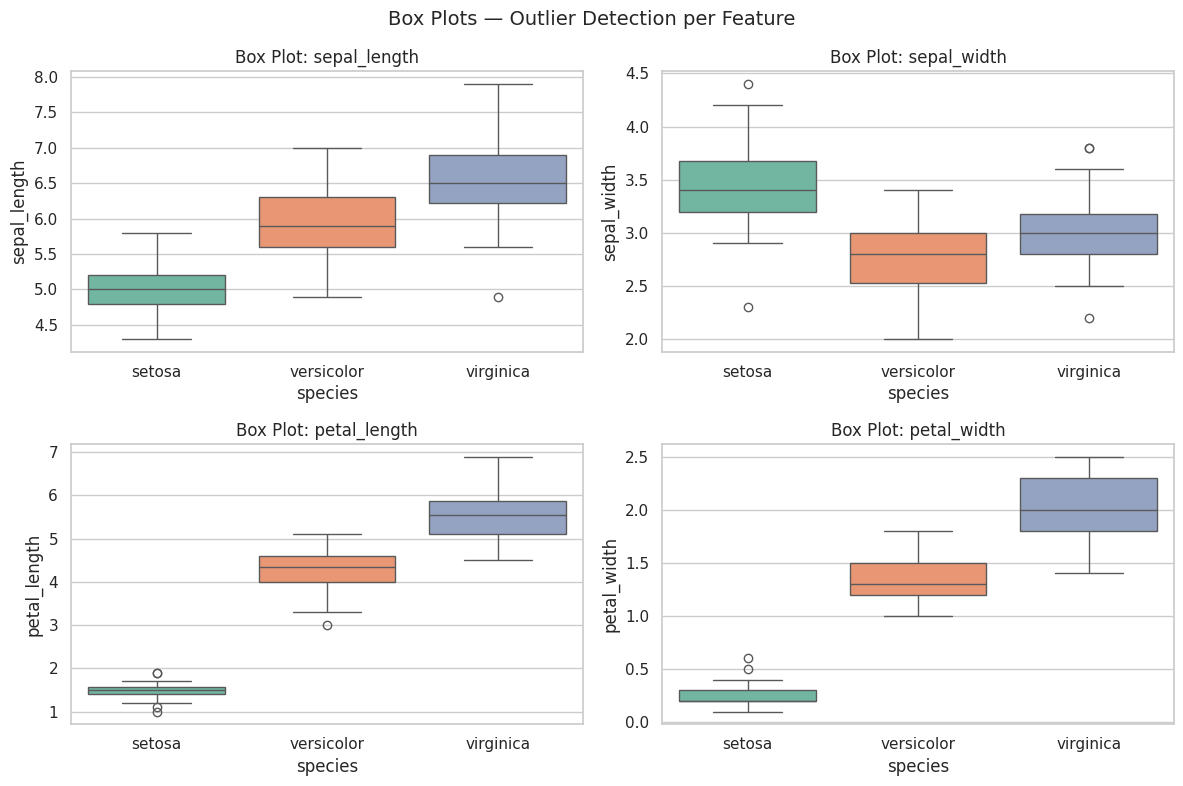

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=df, x='species', y=feature, ax=axes[i], palette='Set2', hue='species', legend=False)
    axes[i].set_title(f'Box Plot: {feature}')

plt.suptitle('Box Plots — Outlier Detection per Feature', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Heatmap — Correlation Matrix

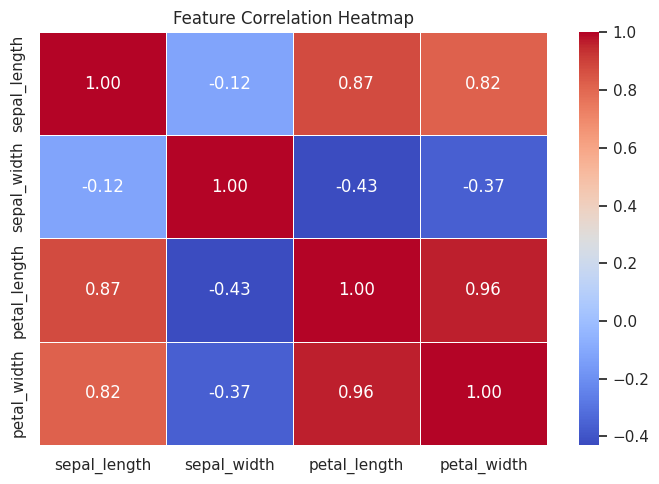

In [10]:
# Compute and visualize feature correlations (numeric columns only)
plt.figure(figsize=(7, 5))
corr = df.drop(columns='species').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 7. Key Insights & Findings

- **No missing values** — the dataset is clean and ready to use.
- **Setosa** is clearly separable from the other two species based on petal dimensions.
- **Petal length** and **petal width** are highly correlated (r ≈ 0.96) and the strongest features for species differentiation.
- **Sepal width** shows minor overlap between species and has the least discriminative power.
- Box plots reveal a few outliers in sepal width for Setosa, but overall the data is well-distributed.